# Notebook 06 — XGBoost under multiple evaluation strategies

**Goal:** Mirror Notebook 05 (Lasso) exactly, but with XGBoost as the model.
This produces a baseline directly comparable to Lasso, under the same three
validation strategies (temporal_holdout, temporal_blocked_kfold, leave_one_site_out)
and the same 3 targets × 3 inputs grid.

**Setup:**
- Model: `XGBRegressor` on GPU (`device='cuda'`, `tree_method='hist'`).
- Inner CV: `GridSearchCV(cv=5)` over 12 hyperparameter combinations
  (max_depth × learning_rate × n_estimators).
- Targets: temperature, salinity, Chl_a_log1p.
- Inputs: 16S clean, 18S clean, combined 16S+18S.

**Output:** `results/phase1_xgboost_3targets_3inputs_3strategies.csv`

In [4]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Make src/ importable
sys.path.insert(0, str(Path("..").resolve()))

from src.cv_strategies import (
    random_kfold,
    temporal_holdout,
    temporal_blocked_kfold,
    leave_one_site_out,
)
from src.xgboost_evaluator import run_xgboost_with_splits, XGB_PARAM_GRID

# Quick GPU check
import xgboost as xgb
import torch
print(f"XGBoost version:  {xgb.__version__}")
print(f"PyTorch CUDA:     {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detected:     {torch.cuda.get_device_name(0)}")
print(f"\nGrid: {XGB_PARAM_GRID}")
print(f"Combinations per outer fold: "
      f"{len(XGB_PARAM_GRID['max_depth']) * len(XGB_PARAM_GRID['learning_rate']) * len(XGB_PARAM_GRID['n_estimators'])}")

XGBoost version:  3.2.0
PyTorch CUDA:     True
GPU detected:     NVIDIA L40S

Grid: {'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1], 'n_estimators': [200, 500]}
Combinations per outer fold: 12


In [5]:
# Load all cleaned tables produced by Notebook 02 (with log1p applied)
PROCESSED_DIR = Path("../data/processed")

meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)

# Build combined matrix (same as in Notebooks 03 and 05)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# Sanity checks
assert (meta.index == otu_16s.index).all(),  "meta vs 16S misaligned"
assert (meta.index == otu_18s.index).all(),  "meta vs 18S misaligned"
assert otu_combined.columns.is_unique,        "duplicate columns in combined"
assert 'Chl_a_log1p' in meta.columns,         "Chl_a_log1p column missing — re-run Notebook 02"

print(f"meta:         {meta.shape}")
print(f"otu_16s:      {otu_16s.shape}")
print(f"otu_18s:      {otu_18s.shape}")
print(f"otu_combined: {otu_combined.shape}")
print(f"\n✓ All tables aligned.")
print(f"✓ Chl_a_log1p column is available in meta.")

meta:         (1538, 24)
otu_16s:      (1538, 1236)
otu_18s:      (1538, 1054)
otu_combined: (1538, 2290)

✓ All tables aligned.
✓ Chl_a_log1p column is available in meta.


In [6]:
# ---- Experiment configuration ----
RANDOM_SEED = 42

# Map (target_column, log_target_flag) for each target.
# Chl_a uses the pre-transformed Chl_a_log1p column from Notebook 02,
# so log_target=False here (the log is already done).
TARGETS = [
    {'name': 'temperature',   'col': 'temperature',  'log': False},
    {'name': 'salinity',      'col': 'salinity',     'log': False},
    {'name': 'Chl_a (log1p)', 'col': 'Chl_a_log1p',  'log': False},
]

# Map input name → DataFrame
INPUTS = {
    '16S':     otu_16s,
    '18S':     otu_18s,
    '16S+18S': otu_combined,
}

# Three validation strategies — identical to Notebook 05 for direct comparison.
STRATEGIES = ['temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

# All results will accumulate here, one row per (target × input × strategy) cell
all_rows = []

print(f"Random seed:   {RANDOM_SEED}")
print(f"Targets ({len(TARGETS)}):    {[t['name'] for t in TARGETS]}")
print(f"Inputs ({len(INPUTS)}):     {list(INPUTS.keys())}")
print(f"Strategies ({len(STRATEGIES)}): {STRATEGIES}")
print(f"\nTotal runs to do: {len(TARGETS) * len(INPUTS) * len(STRATEGIES)} = "
      f"{len(TARGETS)} × {len(INPUTS)} × {len(STRATEGIES)}")

Random seed:   42
Targets (3):    ['temperature', 'salinity', 'Chl_a (log1p)']
Inputs (3):     ['16S', '18S', '16S+18S']
Strategies (3): ['temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

Total runs to do: 27 = 3 × 3 × 3


In [7]:
def build_splits(strategy_name, meta_valid, random_seed=42):
    """
    Dispatch to the right cv_strategies function based on strategy name.
    Returns a list of (train_idx, test_idx) tuples — indices into meta_valid.
    """
    n = len(meta_valid)

    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)

    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)

    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)

    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)

    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")


# Quick dispatch test on temperature target
_test_valid_mask = meta['temperature'].notna()
_test_meta_valid = meta.loc[_test_valid_mask].reset_index(drop=True)
print("Quick dispatch test on temperature target:")
for s in STRATEGIES:
    splits = build_splits(s, _test_meta_valid, RANDOM_SEED)
    print(f"  {s:30s}  →  {len(splits)} folds")

Quick dispatch test on temperature target:
  temporal_holdout                →  1 folds
  temporal_blocked_kfold          →  5 folds
  leave_one_site_out              →  14 folds


In [ ]:
# Smoke test 

# Filter to valid samples for temperature
target_col = 'temperature'
valid_mask = meta[target_col].notna()
meta_v = meta.loc[valid_mask].reset_index(drop=True)
otu_v  = otu_16s.loc[valid_mask].reset_index(drop=True)

print(f"Valid samples for {target_col}: {len(meta_v)}")

# Build splits for the simplest strategy
splits = build_splits('temporal_holdout', meta_v, RANDOM_SEED)

# Run the evaluator
t0 = time.time()
res_smoke = run_xgboost_with_splits(
    target_name   = target_col,
    meta          = meta_v,
    otu           = otu_v,
    splits        = splits,
    strategy_name = 'temporal_holdout',
    input_name    = '16S',
    log_target    = False,
    random_seed   = RANDOM_SEED,
    verbose       = True,
)
elapsed = time.time() - t0

print(f"\n{'=' * 64}")
print(f"Smoke test complete in {elapsed:.1f}s ({elapsed/60:.1f} min).")
print(f"R²    = {res_smoke['r2_mean']:+.4f}")
print(f"MAE   = {res_smoke['mae_mean']:.3f} °C")
print(f"RMSE  = {res_smoke['rmse_mean']:.3f} °C")
print(f"Best params (mode): max_depth={res_smoke['best_max_depth_mode']}, "
      f"lr={res_smoke['best_lr_mode']}, n_est={res_smoke['best_n_est_mode']}")

Valid samples for temperature: 1223

  XGBoost · input=16S · target=temperature · strategy=temporal_holdout
  Samples: 1223    Features: 1236    Folds: 1
  Inner-CV grid: 12 combos × 5-fold = 60 fits per outer fold
    Fold  1: R²=+0.3160  MAE=1.512  RMSE=1.883  best=(d=3, lr=0.05, n=500)  time=42.1s

  Summary · temperature · 16S · temporal_holdout
    R²:    +0.3160  ±  0.0000
    MAE:   1.512  ±  0.000
    RMSE:  1.883  ±  0.000
    Most common best params: max_depth=3, lr=0.05, n_est=500
    Total CV time:           42.1s

Smoke test complete in 42.2s (0.7 min).
R²    = +0.3160
MAE   = 1.512 °C
RMSE  = 1.883 °C
Best params (mode): max_depth=3, lr=0.05, n_est=500


In [ ]:
# Main grid: 3 targets × 3 inputs × 3 strategies = 27 runs.

OUTPUT_CSV = Path("../results/phase1_xgboost_3targets_3inputs_3strategies.csv")
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# Scalar columns to write to CSV (per-fold lists are kept in memory only)
CSV_COLS = [
    'target_display', 'target', 'input', 'strategy',
    'log_target', 'n_samples', 'n_features', 'n_folds',
    'r2_mean', 'r2_std',
    'mae_mean', 'mae_std',
    'rmse_mean', 'rmse_std',
    'best_max_depth_mode', 'best_lr_mode', 'best_n_est_mode',
    'total_time',
]


def save_partial(rows, path):
    """Convert all_rows so far to a DataFrame and overwrite the CSV."""
    if not rows:
        return
    df = pd.DataFrame(rows)[CSV_COLS].round({
        'r2_mean': 4,  'r2_std': 4,
        'mae_mean': 3, 'mae_std': 3,
        'rmse_mean': 3, 'rmse_std': 3,
        'total_time': 1,
    })
    df.to_csv(path, index=False)


# Reset accumulator (in case smoke test or earlier runs left state)
all_rows = []

t_global_start = time.time()
total_runs = len(TARGETS) * len(INPUTS) * len(STRATEGIES)
run_counter = 0

for target in TARGETS:
    target_name = target['name']
    target_col  = target['col']
    log_flag    = target['log']

    # Filter once per target — same samples used across all (input, strategy) cells
    valid_mask  = meta[target_col].notna()
    meta_valid  = meta.loc[valid_mask].reset_index(drop=True)

    for input_name, otu_df in INPUTS.items():
        otu_valid = otu_df.loc[valid_mask].reset_index(drop=True)

        for strategy_name in STRATEGIES:
            run_counter += 1
            elapsed_total = (time.time() - t_global_start) / 60

            print(f"\n{'#' * 64}")
            print(f"# Run {run_counter}/{total_runs}  ·  elapsed so far: {elapsed_total:.1f} min")
            print(f"# target={target_name}  input={input_name}  strategy={strategy_name}")
            print(f"{'#' * 64}")

            splits = build_splits(strategy_name, meta_valid, RANDOM_SEED)

            res = run_xgboost_with_splits(
                target_name   = target_col,
                meta          = meta_valid,
                otu           = otu_valid,
                splits        = splits,
                strategy_name = strategy_name,
                input_name    = input_name,
                log_target    = log_flag,
                random_seed   = RANDOM_SEED,
                verbose       = True,
            )

            # Use the display name (e.g. 'Chl_a (log1p)') in the results row
            res['target_display'] = target_name
            all_rows.append(res)

            # Incremental save after every run
            save_partial(all_rows, OUTPUT_CSV)
            print(f"  → partial results saved ({len(all_rows)}/{total_runs} rows in CSV)")

t_global_end = time.time()
total_min = (t_global_end - t_global_start) / 60

print(f"\n{'=' * 64}")
print(f"All {total_runs} runs complete in {total_min:.1f} minutes ({total_min/60:.1f} hours).")
print(f"Collected {len(all_rows)} result dicts in `all_rows`.")
print(f"Final CSV: {OUTPUT_CSV}")


################################################################
# Run 1/27  ·  elapsed so far: 0.0 min
# target=temperature  input=16S  strategy=temporal_holdout
################################################################

  XGBoost · input=16S · target=temperature · strategy=temporal_holdout
  Samples: 1223    Features: 1236    Folds: 1
  Inner-CV grid: 12 combos × 5-fold = 60 fits per outer fold
    Fold  1: R²=+0.3160  MAE=1.512  RMSE=1.883  best=(d=3, lr=0.05, n=500)  time=98.0s

  Summary · temperature · 16S · temporal_holdout
    R²:    +0.3160  ±  0.0000
    MAE:   1.512  ±  0.000
    RMSE:  1.883  ±  0.000
    Most common best params: max_depth=3, lr=0.05, n_est=500
    Total CV time:           98.0s
  → partial results saved (1/27 rows in CSV)

################################################################
# Run 2/27  ·  elapsed so far: 1.6 min
# target=temperature  input=16S  strategy=temporal_blocked_kfold
############################################################

---

# Section: Site 6 Investigation

LOSO revealed that one site — the 6th in the LOSO fold ordering — causes
catastrophic failure for salinity (R² down to −794) and a notable dip for
temperature (R²=0.16 on 16S, vs ~0.97 for all other sites).

This section identifies the site and characterises why it differs from the
rest, so we have a clear answer ready for the supervisor meeting.

In [ ]:
# Step 1: Identify which site corresponds to fold 6 in LOSO

target_col = 'temperature'   # same as the runs above
valid_mask = meta[target_col].notna()
meta_v     = meta.loc[valid_mask].reset_index(drop=True)

splits_loso = leave_one_site_out(meta_v)

print(f"LOSO produced {len(splits_loso)} folds (one per site).")
print()
print("Site held out in each fold (for temperature target):")
print("-" * 70)

site_per_fold = []
for fold_idx, (train_idx, test_idx) in enumerate(splits_loso, start=1):
    site   = meta_v.iloc[test_idx]['location_name'].iloc[0]
    n_test = len(test_idx)
    marker = "  ⚠️ THE PROBLEM SITE" if fold_idx == 6 else ""
    print(f"  Fold {fold_idx:2d}: {site:35s} ({n_test:4d} test samples){marker}")
    site_per_fold.append(site)

# Capture the problem site name for downstream cells
SITE_6_NAME = site_per_fold[5]    # 0-indexed: fold 6 → index 5
print(f"\n→ Fold 6 corresponds to site:  '{SITE_6_NAME}'")

LOSO produced 14 folds (one per site).

Site held out in each fold (for temperature target):
----------------------------------------------------------------------
  Fold  1: Boergerende Strand                  (  87 test samples)
  Fold  2: Diedrichshagen                      (  84 test samples)
  Fold  3: Elmenhorst Strand                   (  82 test samples)
  Fold  4: Jemnitzschleuse                     (  88 test samples)
  Fold  5: Mittelmole Warnemuende              (  89 test samples)
  Fold  6: Muehlendamm                         (  91 test samples)  ⚠️ THE PROBLEM SITE
  Fold  7: Neptun-Werft                        (  90 test samples)
  Fold  8: Parkplatz zur Warnow                (  89 test samples)
  Fold  9: SAB Marina Bramow                   (  91 test samples)
  Fold 10: Schmarl-Dorf / IGA-Park             (  88 test samples)
  Fold 11: Schwimmhalle Gehlsdorf              (  86 test samples)
  Fold 12: Stadthafen Rostock                  (  89 test samples)
  Fold 13: 

In [ ]:
# Step 2: Characterise Muehlendamm vs all other sites.

site6  = meta[meta['location_name'] == SITE_6_NAME]
others = meta[meta['location_name'] != SITE_6_NAME]

print(f"Sample counts:")
print(f"  {SITE_6_NAME:30s}  n = {len(site6)}")
print(f"  All other sites combined      n = {len(others)}")
print()

# Compare key environmental variables
key_vars = ['temperature', 'salinity', 'Chl_a', 'NH4', 'NO3', 'PO4', 'O2']
key_vars = [c for c in key_vars if c in meta.columns]

print(f"{'Variable':<14}  {'Source':<10}  {'mean':>8}  {'std':>7}  {'min':>8}  {'max':>8}  {'n':>5}")
print("-" * 78)

for col in key_vars:
    s6_vals  = site6[col].dropna()
    oth_vals = others[col].dropna()

    if len(s6_vals) > 0:
        print(f"{col:<14}  {SITE_6_NAME[:10]:<10}  "
              f"{s6_vals.mean():>8.2f}  {s6_vals.std():>7.2f}  "
              f"{s6_vals.min():>8.2f}  {s6_vals.max():>8.2f}  {len(s6_vals):>5d}")
    if len(oth_vals) > 0:
        print(f"{'':<14}  {'others':<10}  "
              f"{oth_vals.mean():>8.2f}  {oth_vals.std():>7.2f}  "
              f"{oth_vals.min():>8.2f}  {oth_vals.max():>8.2f}  {len(oth_vals):>5d}")
    print()

Sample counts:
  Muehlendamm                     n = 109
  All other sites combined      n = 1429

Variable        Source          mean      std       min       max      n
------------------------------------------------------------------------------
temperature     Muehlendam     11.38     7.22      0.50     24.30     91
                others         10.89     6.22      0.30     24.46   1132

salinity        Muehlendam      0.45     0.27      0.10      0.84     90
                others         13.18     4.20     -0.01     23.80   1127

Chl_a           Muehlendam     14.74    12.75      0.26     62.09    103
                others          4.49     9.95      0.00    156.96   1334

NH4             Muehlendam      4.51     6.69      0.00     33.24    108
                others          2.60     3.83      0.00     35.04   1423

NO3             Muehlendam     43.20    99.06      0.20    926.24    108
                others         11.84    35.34     -0.12    727.20   1423

PO4           

In [ ]:
# Re-setup after kernel restart, then run 9 random_kfold cells

import sys, time
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.cv_strategies import (
    random_kfold, temporal_holdout,
    temporal_blocked_kfold, leave_one_site_out,
)
from src.xgboost_evaluator import run_xgboost_with_splits

# ---- Reload data ----
PROCESSED_DIR = Path("../data/processed")
meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# ---- Configuration ----
RANDOM_SEED = 42
TARGETS = [
    {'name': 'temperature',   'col': 'temperature',  'log': False},
    {'name': 'salinity',      'col': 'salinity',     'log': False},
    {'name': 'Chl_a (log1p)', 'col': 'Chl_a_log1p',  'log': False},
]
INPUTS = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_combined}

def build_splits(strategy_name, meta_valid, random_seed=42):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f"Unknown strategy: {strategy_name}")

CSV_COLS = [
    'target_display','target','input','strategy','log_target',
    'n_samples','n_features','n_folds',
    'r2_mean','r2_std','mae_mean','mae_std','rmse_mean','rmse_std',
    'best_max_depth_mode','best_lr_mode','best_n_est_mode','total_time',
]
def save_partial(rows, path):
    if not rows: return
    pd.DataFrame(rows)[CSV_COLS].round({
        'r2_mean':4,'r2_std':4,'mae_mean':3,'mae_std':3,
        'rmse_mean':3,'rmse_std':3,'total_time':1,
    }).to_csv(path, index=False)

# ---- Load existing 27 runs and rebuild all_rows ----
EXISTING_CSV = Path("../results/phase1_xgboost_3targets_3inputs_3strategies.csv")
all_rows = pd.read_csv(EXISTING_CSV).to_dict('records')
print(f"Loaded {len(all_rows)} existing runs from {EXISTING_CSV.name}")

# ---- Run the 9 missing random_kfold cells ----
NEW_OUTPUT_CSV = Path("../results/phase1_xgboost_3targets_3inputs_4strategies.csv")

t0 = time.time()
new_run = 0

for target in TARGETS:
    target_name, target_col, log_flag = target['name'], target['col'], target['log']
    valid_mask = meta[target_col].notna()
    meta_valid = meta.loc[valid_mask].reset_index(drop=True)

    for input_name, otu_df in INPUTS.items():
        otu_valid = otu_df.loc[valid_mask].reset_index(drop=True)
        new_run += 1
        elapsed = (time.time() - t0) / 60
        print(f"\n{'#' * 64}")
        print(f"# Random kfold {new_run}/9  ·  elapsed: {elapsed:.1f} min")
        print(f"# target={target_name}  input={input_name}")
        print(f"{'#' * 64}")

        splits = build_splits('random_kfold', meta_valid, RANDOM_SEED)
        res = run_xgboost_with_splits(
            target_name=target_col, meta=meta_valid, otu=otu_valid,
            splits=splits, strategy_name='random_kfold',
            input_name=input_name, log_target=log_flag,
            random_seed=RANDOM_SEED, verbose=True,
        )
        res['target_display'] = target_name
        all_rows.append(res)
        save_partial(all_rows, NEW_OUTPUT_CSV)

total_min = (time.time() - t0) / 60
print(f"\n{'=' * 64}")
print(f"All 9 random_kfold runs complete in {total_min:.1f} min.")
print(f"Total all_rows entries: {len(all_rows)}  (should be 36)")
print(f"Final CSV: {NEW_OUTPUT_CSV}")

Loaded 27 existing runs from phase1_xgboost_3targets_3inputs_3strategies.csv

################################################################
# Random kfold 1/9  ·  elapsed: 0.0 min
# target=temperature  input=16S
################################################################

  XGBoost · input=16S · target=temperature · strategy=random_kfold
  Samples: 1223    Features: 1236    Folds: 5
  Inner-CV grid: 12 combos × 5-fold = 60 fits per outer fold
    Fold  1: R²=+0.9648  MAE=0.800  RMSE=1.175  best=(d=3, lr=0.1, n=500)  time=41.0s
    Fold  2: R²=+0.9759  MAE=0.765  RMSE=1.003  best=(d=5, lr=0.05, n=500)  time=41.3s
    Fold  3: R²=+0.9736  MAE=0.822  RMSE=1.060  best=(d=3, lr=0.05, n=500)  time=41.2s
    Fold  4: R²=+0.9613  MAE=0.889  RMSE=1.199  best=(d=3, lr=0.1, n=500)  time=40.8s
    Fold  5: R²=+0.9679  MAE=0.795  RMSE=1.090  best=(d=3, lr=0.1, n=500)  time=40.6s

  Summary · temperature · 16S · random_kfold
    R²:    +0.9687  ±  0.0054
    MAE:   0.814  ±  0.042
    RMSE: 

Saved: ../results/phase1_xgboost_heatmap.png


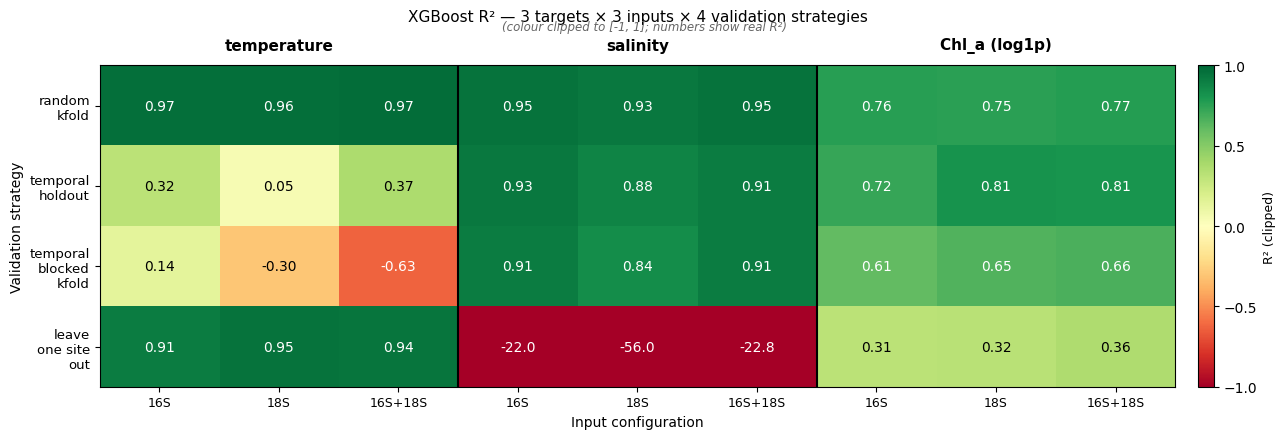

In [2]:
import matplotlib.pyplot as plt

strategy_order = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
strategy_labels = ['random\nkfold', 'temporal\nholdout', 'temporal\nblocked\nkfold', 'leave\none site\nout']
target_order   = ['temperature', 'salinity', 'Chl_a (log1p)']
input_order    = ['16S', '18S', '16S+18S']

df = pd.DataFrame([{
    'target_display': r['target_display'], 'input': r['input'],
    'strategy': r['strategy'], 'r2_mean': r['r2_mean'],
} for r in all_rows])

pivot_xgb = df.pivot_table(
    index='strategy', columns=['target_display','input'],
    values='r2_mean', observed=True,
).reindex(
    index=strategy_order,
    columns=pd.MultiIndex.from_product([target_order, input_order]),
)
vals  = pivot_xgb.values
clipd = np.clip(vals, -1, 1)

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(clipd, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(9)); ax.set_xticklabels(input_order * 3, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(strategy_labels, fontsize=9.5)

for t_idx, target in enumerate(target_order):
    ax.text(t_idx * 3 + 1, -0.75, target, ha='center', va='center',
            fontsize=11, fontweight='bold')
for sep_x in [2.5, 5.5]:
    ax.axvline(sep_x, color='black', linewidth=1.5)

for i in range(4):
    for j in range(9):
        v = vals[i, j]
        if abs(v) >= 100:    txt = f"{v:.0f}"
        elif abs(v) >= 10:   txt = f"{v:.1f}"
        else:                 txt = f"{v:.2f}"
        color = 'white' if abs(clipd[i, j]) > 0.6 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=10, color=color)

ax.set_title("XGBoost R² — 3 targets × 3 inputs × 4 validation strategies",
             fontsize=11, pad=32)
fig.text(0.5, 0.92, "(colour clipped to [-1, 1]; numbers show real R²)",
         ha='center', fontsize=8.5, style='italic', color='#666666')
ax.set_xlabel("Input configuration", fontsize=10)
ax.set_ylabel("Validation strategy", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("R² (clipped)", fontsize=9)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

plt.tight_layout()
out_path = Path("../results/phase1_xgboost_heatmap.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_path}")
plt.show()

Lasso CSV columns: ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time']
Unique target values: <StringArray>
['temperature', 'salinity', 'Chl_a (log1p)']
Length: 3, dtype: str
Lasso target_display values: <StringArray>
['temperature', 'salinity', 'Chl_a (log1p)']
Length: 3, dtype: str
Saved: ../results/phase1_comparison_heatmap.png


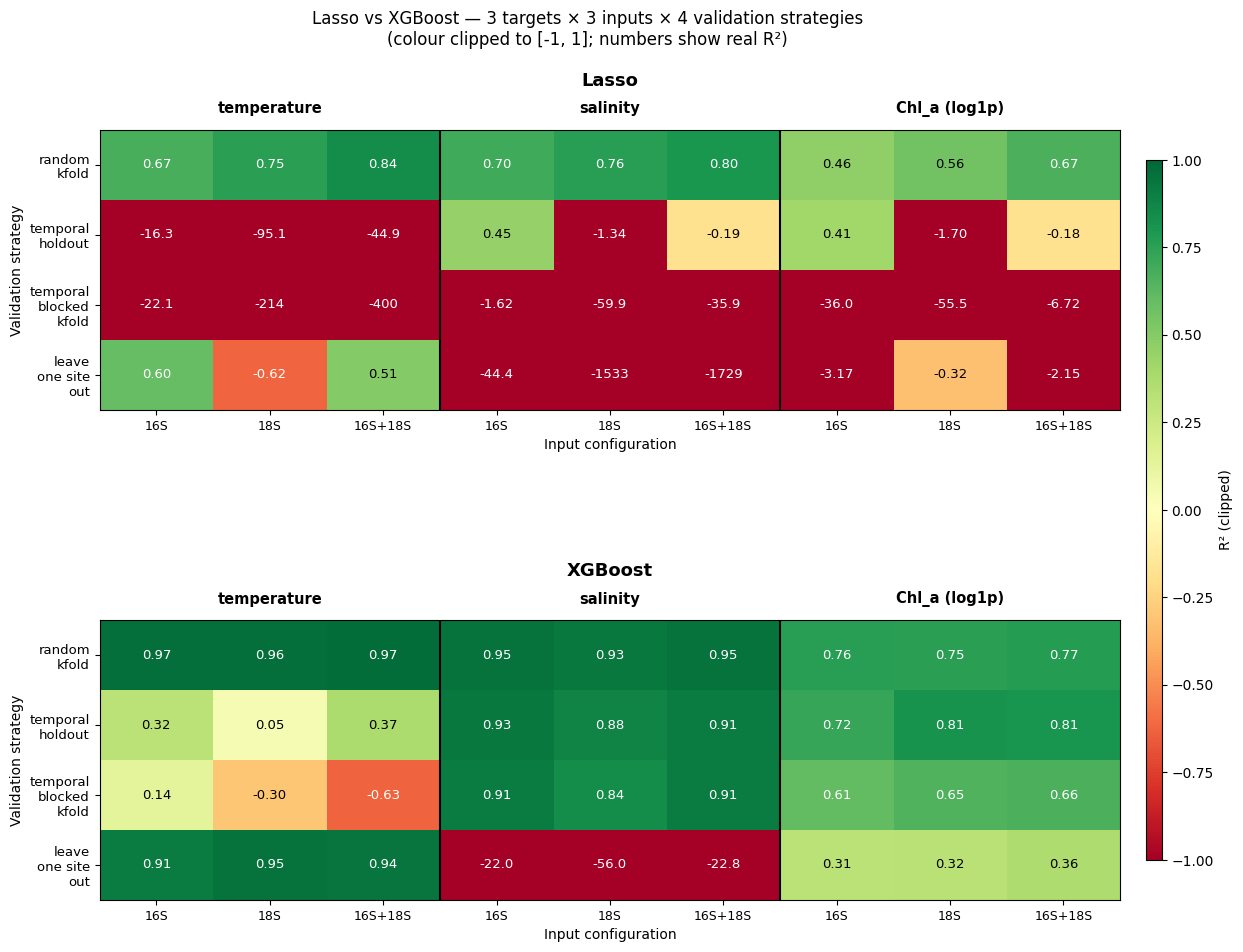

In [4]:
# ---- Step 1: Load Lasso CSV and inspect columns ----
df_lasso = pd.read_csv("../results/phase1_lasso_3targets_3inputs_4strategies.csv")
print("Lasso CSV columns:", list(df_lasso.columns))
print("Unique target values:", df_lasso['target'].unique() if 'target' in df_lasso.columns else "no target col")

# ---- Step 2: Ensure target_display exists in both dataframes ----
target_map = {
    'temperature':   'temperature',
    'salinity':      'salinity',
    'Chl_a_log1p':   'Chl_a (log1p)',
    'Chl_a':         'Chl_a (log1p)',
    'Chl_a (log1p)': 'Chl_a (log1p)',
}

if 'target_display' not in df_lasso.columns:
    if 'target' in df_lasso.columns:
        df_lasso['target_display'] = df_lasso['target'].map(target_map).fillna(df_lasso['target'])
    else:
        raise KeyError(f"Cannot find target column. Found: {list(df_lasso.columns)}")

print("Lasso target_display values:", df_lasso['target_display'].unique())

# ---- Step 3: Build pivot tables ----
def make_pivot(d):
    return d.pivot_table(
        index='strategy', columns=['target_display','input'],
        values='r2_mean', observed=True,
    ).reindex(
        index=strategy_order,
        columns=pd.MultiIndex.from_product([target_order, input_order]),
    )

pivot_lasso = make_pivot(df_lasso)

# ---- Step 4: Plot ----
fig, axes = plt.subplots(2, 1, figsize=(13, 10),
                          gridspec_kw={'hspace': 0.75})

for ax, (name, pv) in zip(axes, [('Lasso', pivot_lasso), ('XGBoost', pivot_xgb)]):
    vals  = pv.values
    clipd = np.clip(vals, -1, 1)
    im = ax.imshow(clipd, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(range(9)); ax.set_xticklabels(input_order * 3, fontsize=9)
    ax.set_yticks(range(4)); ax.set_yticklabels(strategy_labels, fontsize=9.5)

    for t_idx, target in enumerate(target_order):
        ax.text(t_idx * 3 + 1, -0.8, target, ha='center', va='center',
                fontsize=10.5, fontweight='bold')
    for sep_x in [2.5, 5.5]:
        ax.axvline(sep_x, color='black', linewidth=1.5)

    for i in range(4):
        for j in range(9):
            v = vals[i, j]
            if abs(v) >= 100:    txt = f"{v:.0f}"
            elif abs(v) >= 10:   txt = f"{v:.1f}"
            else:                 txt = f"{v:.2f}"
            color = 'white' if abs(clipd[i, j]) > 0.6 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9.5, color=color)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=32)
    ax.set_xlabel("Input configuration", fontsize=10)
    ax.set_ylabel("Validation strategy", fontsize=10)

fig.suptitle("Lasso vs XGBoost — 3 targets × 3 inputs × 4 validation strategies\n"
             "(colour clipped to [-1, 1]; numbers show real R²)",
             fontsize=12, y=1.0)

fig.subplots_adjust(right=0.91)
cbar_ax = fig.add_axes([0.93, 0.15, 0.012, 0.7])
fig.colorbar(im, cax=cbar_ax, label='R² (clipped)')

out_path = Path("../results/phase1_comparison_heatmap.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_path}")
plt.show()

In [6]:
df_lasso_t = df_lasso.copy(); df_lasso_t['model'] = 'Lasso'
df_xgb_t   = df.copy();       df_xgb_t['model']   = 'XGBoost'

cols = ['target_display','input','strategy','r2_mean','model']
combined = pd.concat([df_lasso_t[cols], df_xgb_t[cols]], ignore_index=True)

wide = combined.pivot_table(
    index=['target_display','input','strategy'],
    columns='model', values='r2_mean',
).reindex(
    index=pd.MultiIndex.from_product(
        [target_order, input_order, strategy_order],
        names=['target_display', 'input', 'strategy']   # ← این خط جدید بود
    ),
    columns=['Lasso','XGBoost'],
)
wide['Δ (XGB - Lasso)'] = wide['XGBoost'] - wide['Lasso']
wide = wide.round(3)

print("=" * 95)
print(" R² mean · Lasso vs XGBoost · all 36 cells")
print("=" * 95)
print(wide.to_string())

xgb_wins   = (wide['Δ (XGB - Lasso)'] > 0).sum()
lasso_wins = (wide['Δ (XGB - Lasso)'] < 0).sum()
print(f"\nXGBoost wins: {xgb_wins}/36 cells")
print(f"Lasso   wins: {lasso_wins}/36 cells")

print("\n--- XGBoost advantage by strategy ---")
for s in strategy_order:
    s_rows = wide.xs(s, level='strategy')
    mean_delta = s_rows['Δ (XGB - Lasso)'].mean()
    n_wins = (s_rows['Δ (XGB - Lasso)'] > 0).sum()
    print(f"  {s:25s}  mean Δ = {mean_delta:+8.2f}   XGB wins: {n_wins}/9")

wide.to_csv("../results/phase1_lasso_vs_xgboost_final.csv")
print("\nSaved: ../results/phase1_lasso_vs_xgboost_final.csv")

 R² mean · Lasso vs XGBoost · all 36 cells
model                                             Lasso  XGBoost  Δ (XGB - Lasso)
target_display input   strategy                                                  
temperature    16S     random_kfold               0.675    0.969            0.294
                       temporal_holdout         -16.317    0.316           16.633
                       temporal_blocked_kfold   -22.145    0.138           22.282
                       leave_one_site_out         0.600    0.914            0.313
               18S     random_kfold               0.750    0.964            0.214
                       temporal_holdout         -95.112    0.046           95.158
                       temporal_blocked_kfold  -214.351   -0.299          214.052
                       leave_one_site_out        -0.622    0.952            1.573
               16S+18S random_kfold               0.837    0.973            0.136
                       temporal_holdout         -44.935

In [12]:
# ....................  نمودار پلات
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))

from src.cv_strategies import (
    random_kfold, temporal_holdout,
    temporal_blocked_kfold, leave_one_site_out,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Load data
PROCESSED_DIR = Path("../data/processed")
meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# Filter to valid salinity samples
target_col = 'salinity'
valid_mask = meta[target_col].notna()
meta_v = meta.loc[valid_mask].reset_index(drop=True)
X = otu_combined.loc[valid_mask].values
y = meta_v[target_col].values

print(f"Valid samples: {len(y)}")
print(f"Features:      {X.shape[1]}")
print(f"Salinity range: {y.min():.2f} – {y.max():.2f} PSU")
print(f"Muehlendamm samples: {(meta_v['location_name'] == 'Muehlendamm').sum()}")

Valid samples: 1217
Features:      2290
Salinity range: -0.01 – 23.80 PSU
Muehlendamm samples: 90


In [13]:
RANDOM_SEED = 42

def run_and_capture(model_name, X, y, splits, meta_v, seed=RANDOM_SEED):
    """Run CV, return DataFrame of (y_true, y_pred, site, fold) per sample."""
    records = []

    for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        sites_te = meta_v.iloc[test_idx]['location_name'].values

        if model_name == 'Lasso':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso',  LassoCV(cv=5, random_state=seed,
                                   max_iter=10_000, n_jobs=-1)),
            ])
        else:  # XGBoost
            base = XGBRegressor(
                objective='reg:squarederror',
                device='cuda', tree_method='hist',
                random_state=seed, n_jobs=1, verbosity=0,
            )
            grid = {'max_depth': [3, 5, 7],
                    'learning_rate': [0.05, 0.1],
                    'n_estimators': [200, 500]}
            model = GridSearchCV(base, grid, cv=5, scoring='r2', n_jobs=1)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        for yt, yp, site in zip(y_te, y_pred, sites_te):
            records.append({
                'y_true': float(yt), 'y_pred': float(yp),
                'site': site, 'fold': fold_idx,
            })

    return pd.DataFrame(records)

In [14]:
def build_splits(strategy_name, meta_valid, seed=RANDOM_SEED):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=seed)
    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)

strategies = ['random_kfold', 'temporal_holdout',
              'temporal_blocked_kfold', 'leave_one_site_out']

all_predictions = {}
t_global = time.time()

for strategy_name in strategies:
    splits = build_splits(strategy_name, meta_v)
    print(f"\n[{strategy_name}] — {len(splits)} folds")

    for model_name in ['Lasso', 'XGBoost']:
        t0 = time.time()
        print(f"  Running {model_name}...", end=' ', flush=True)
        df_preds = run_and_capture(model_name, X, y, splits, meta_v)
        elapsed = time.time() - t0
        all_predictions[(strategy_name, model_name)] = df_preds

        r2 = r2_score(df_preds['y_true'], df_preds['y_pred'])
        print(f"done in {elapsed:.1f}s  ({len(df_preds)} predictions, R²={r2:+.3f})")

print(f"\n{'=' * 64}")
print(f"All 8 runs complete in {(time.time() - t_global) / 60:.1f} min.")


[random_kfold] — 5 folds
  Running Lasso... done in 63.0s  (1217 predictions, R²=+0.808)
  Running XGBoost... done in 284.0s  (1217 predictions, R²=+0.953)

[temporal_holdout] — 1 folds
  Running Lasso... done in 14.1s  (243 predictions, R²=-0.187)
  Running XGBoost... done in 60.1s  (243 predictions, R²=+0.922)

[temporal_blocked_kfold] — 5 folds
  Running Lasso... done in 59.8s  (1217 predictions, R²=-28.076)
  Running XGBoost... done in 293.4s  (1217 predictions, R²=+0.924)

[leave_one_site_out] — 14 folds
  Running Lasso... done in 206.8s  (1217 predictions, R²=-3.728)
  Running XGBoost... done in 861.3s  (1217 predictions, R²=+0.895)

All 8 runs complete in 30.7 min.


Saved: ../results/parity_plot_salinity.png


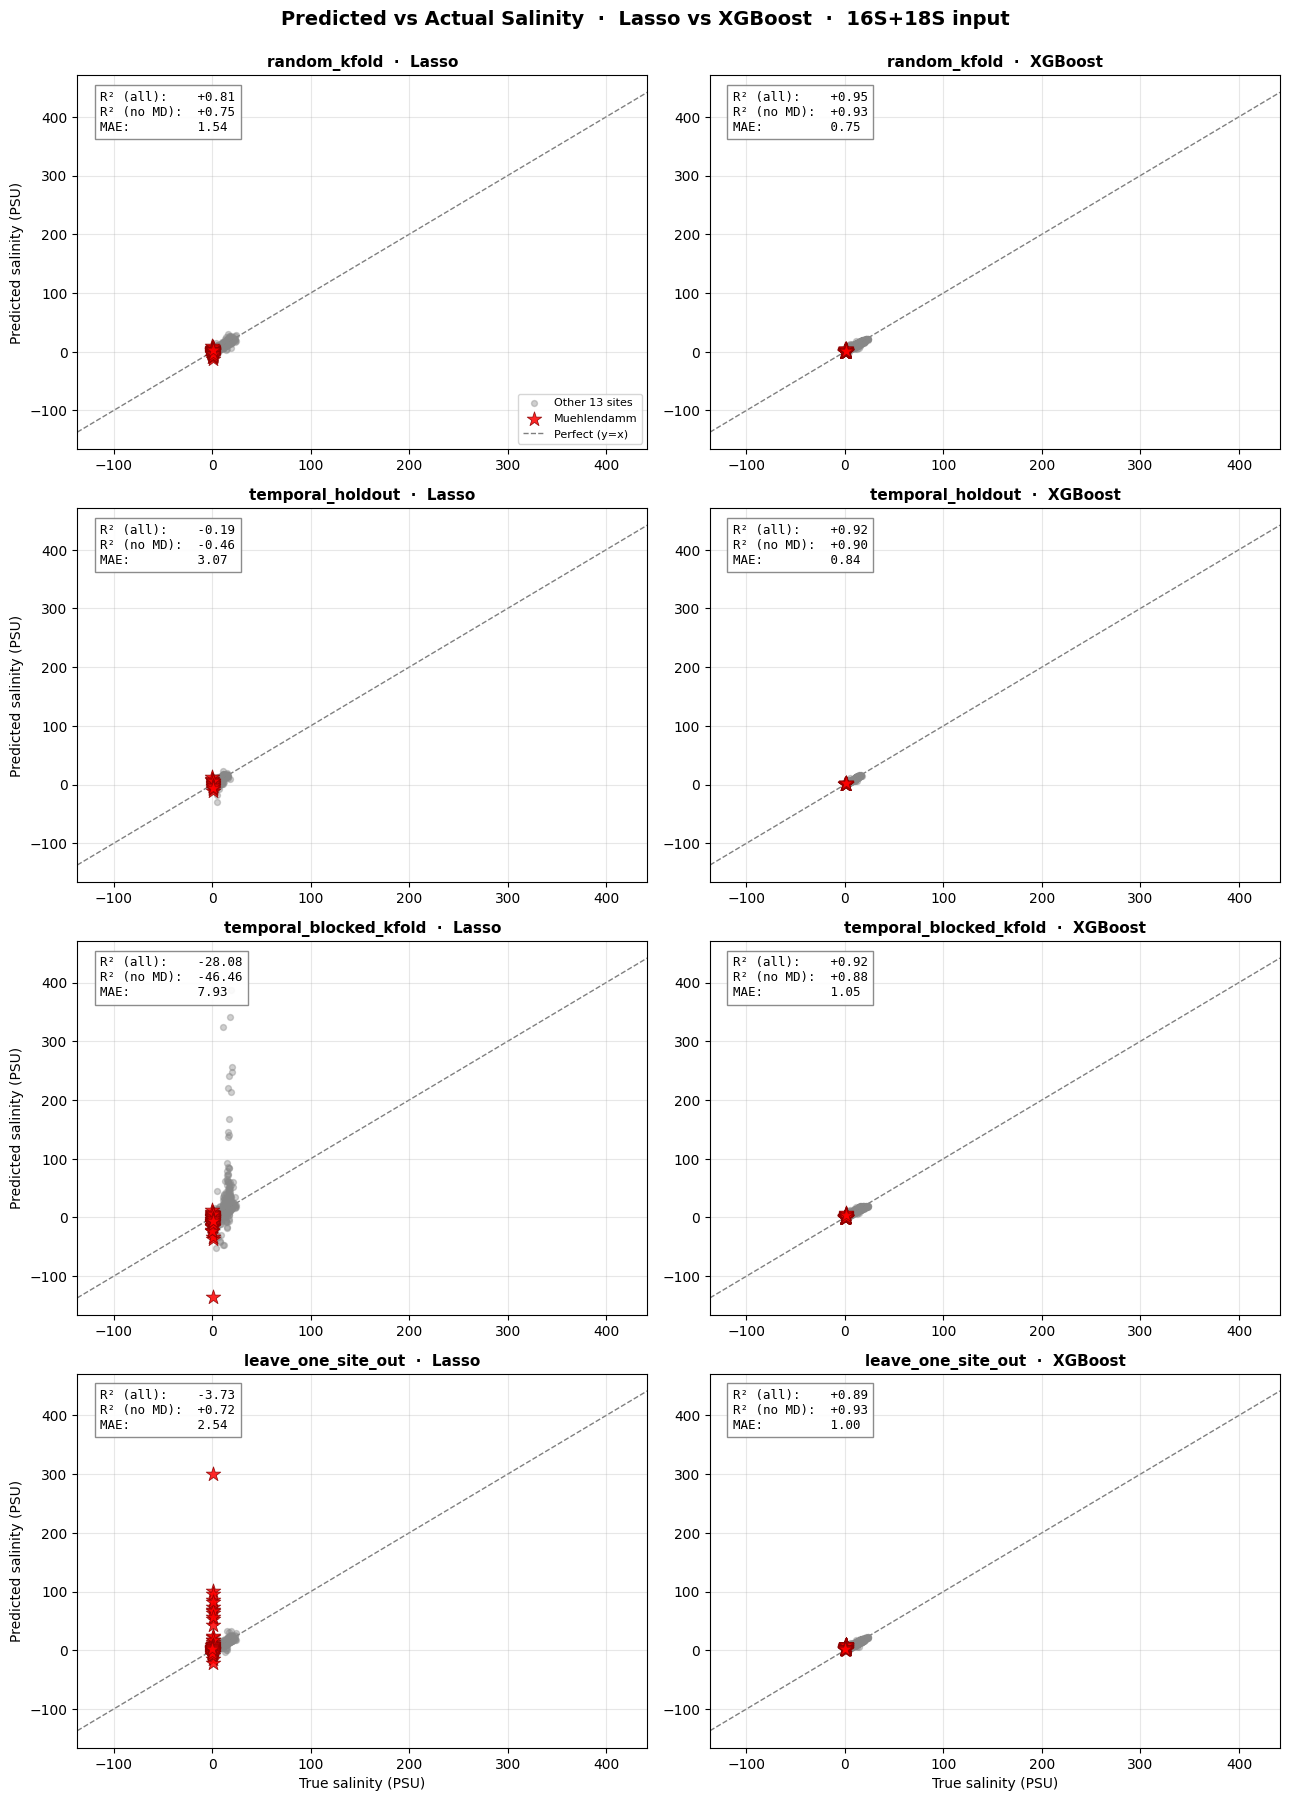

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))

# Limits across all data for consistent axes
all_y_true = np.concatenate([df['y_true'].values for df in all_predictions.values()])
all_y_pred = np.concatenate([df['y_pred'].values for df in all_predictions.values()])
y_min = min(all_y_true.min(), all_y_pred.min()) - 1
y_max = max(all_y_true.max(), all_y_pred.max()) + 1

for row, strategy_name in enumerate(strategies):
    for col, model_name in enumerate(['Lasso', 'XGBoost']):
        ax = axes[row, col]
        df = all_predictions[(strategy_name, model_name)]
        is_md = df['site'] == 'Muehlendamm'

        # Other 13 sites — gray
        ax.scatter(df.loc[~is_md, 'y_true'], df.loc[~is_md, 'y_pred'],
                   c='#888888', s=18, alpha=0.4,
                   label='Other 13 sites', zorder=2)

        # Muehlendamm — red stars
        ax.scatter(df.loc[is_md, 'y_true'], df.loc[is_md, 'y_pred'],
                   c='red', marker='*', s=120, alpha=0.85,
                   edgecolor='darkred', linewidth=0.6,
                   label='Muehlendamm', zorder=3)

        # Reference line y=x (perfect prediction)
        ax.plot([y_min, y_max], [y_min, y_max],
                'k--', linewidth=1, alpha=0.5, zorder=1,
                label='Perfect (y=x)')

        # Per-panel stats
        r2_all  = r2_score(df['y_true'], df['y_pred'])
        mae_all = mean_absolute_error(df['y_true'], df['y_pred'])
        df_nomd = df[~is_md]
        r2_nomd = r2_score(df_nomd['y_true'], df_nomd['y_pred']) if len(df_nomd) else float('nan')

        stats_text = (f"R² (all):    {r2_all:+.2f}\n"
                      f"R² (no MD):  {r2_nomd:+.2f}\n"
                      f"MAE:         {mae_all:.2f}")
        ax.text(0.04, 0.96, stats_text,
                transform=ax.transAxes,
                verticalalignment='top', fontsize=9, family='monospace',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

        ax.set_title(f"{strategy_name}  ·  {model_name}",
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(y_min, y_max)
        # Y axis adjusts per panel — Lasso predictions go wild
        if row == 3:
            ax.set_xlabel('True salinity (PSU)', fontsize=10)
        if col == 0:
            ax.set_ylabel('Predicted salinity (PSU)', fontsize=10)
        if row == 0 and col == 0:
            ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Predicted vs Actual Salinity  ·  Lasso vs XGBoost  ·  16S+18S input',
             fontsize=14, y=0.998, fontweight='bold')

plt.tight_layout()
out_path = Path("../results/parity_plot_salinity.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_path}")
plt.show()

Saved: ../results/parity_plot_salinity_v2.png


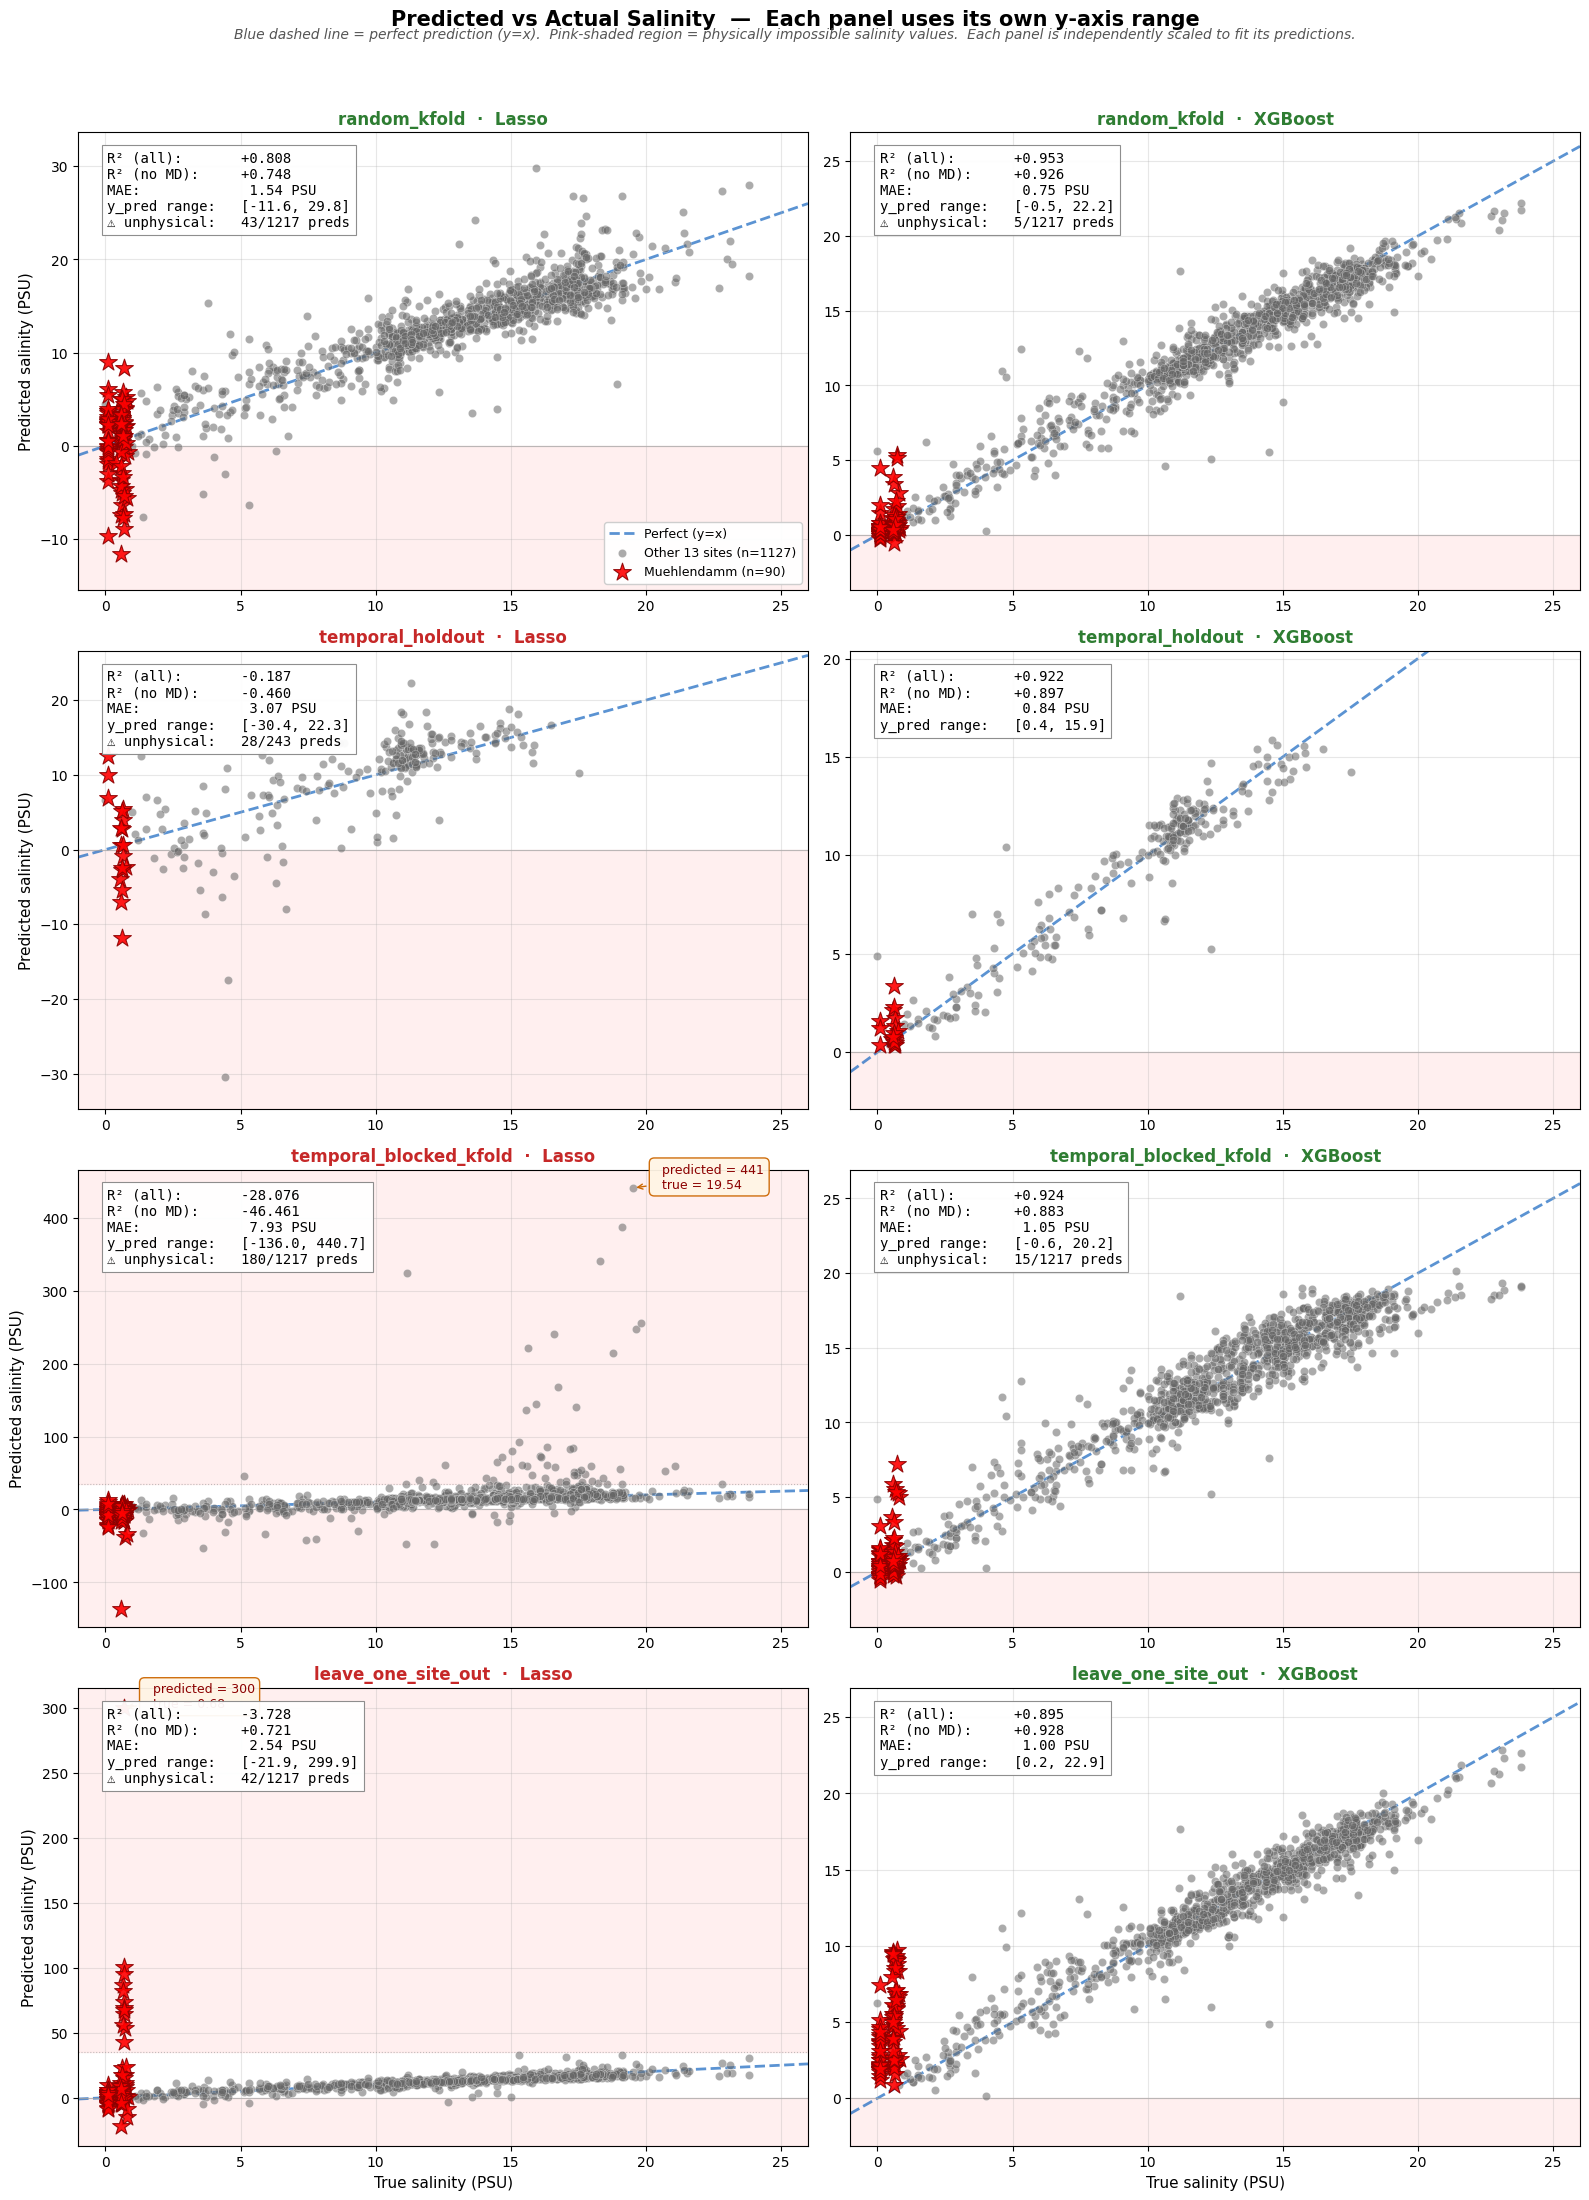

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

# Reasonable physical range for salinity in the Warnow/Baltic
PHYS_MIN, PHYS_MAX = 0, 35  # PSU
# Beyond this, predictions are physically impossible

fig, axes = plt.subplots(4, 2, figsize=(16, 22))  # bigger figure

for row, strategy_name in enumerate(strategies):
    for col, model_name in enumerate(['Lasso', 'XGBoost']):
        ax = axes[row, col]
        df = all_predictions[(strategy_name, model_name)]
        is_md = df['site'] == 'Muehlendamm'

        # --- determine independent axis range for THIS panel ---
        y_min = min(df['y_true'].min(), df['y_pred'].min()) - 2
        y_max = max(df['y_true'].max(), df['y_pred'].max()) + 2
        pad = (y_max - y_min) * 0.04
        y_min -= pad; y_max += pad

        # --- shade physically impossible region (predictions outside 0-35 PSU) ---
        # Anything with y_pred < 0 or y_pred > 35 is unphysical
        if y_min < PHYS_MIN:
            ax.axhspan(y_min, PHYS_MIN, color='#FFE5E5', alpha=0.6,
                       zorder=0)
        if y_max > PHYS_MAX:
            ax.axhspan(PHYS_MAX, y_max, color='#FFE5E5', alpha=0.6,
                       zorder=0)

        # --- reference line y=x (perfect prediction) ---
        lim_low  = min(df['y_true'].min(), 0) - 1
        lim_high = max(df['y_true'].max(), 25) + 1
        ax.plot([lim_low, lim_high], [lim_low, lim_high],
                color='#1565C0', linestyle='--', linewidth=2,
                alpha=0.7, zorder=1, label='Perfect (y=x)')

        # --- physical bounds (0 and 35 PSU lines) ---
        ax.axhline(0, color='#999999', linewidth=0.8, alpha=0.6, zorder=1)
        ax.axhline(35, color='#999999', linewidth=0.8, alpha=0.6, zorder=1,
                   linestyle=':')

        # --- other 13 sites — gray dots ---
        ax.scatter(df.loc[~is_md, 'y_true'], df.loc[~is_md, 'y_pred'],
                   c='#666666', s=35, alpha=0.55, zorder=2,
                   label=f'Other 13 sites (n={(~is_md).sum()})',
                   edgecolor='white', linewidth=0.3)

        # --- Muehlendamm — red stars ---
        ax.scatter(df.loc[is_md, 'y_true'], df.loc[is_md, 'y_pred'],
                   c='red', marker='*', s=180, alpha=0.9, zorder=3,
                   edgecolor='darkred', linewidth=0.8,
                   label=f'Muehlendamm (n={is_md.sum()})')

        # --- annotate the most extreme prediction with its value ---
        max_abs_idx = df['y_pred'].abs().idxmax()
        extreme = df.loc[max_abs_idx]
        if abs(extreme['y_pred']) > 50:  # only annotate if truly extreme
            ax.annotate(f"  predicted = {extreme['y_pred']:.0f}\n  true = {extreme['y_true']:.2f}",
                        xy=(extreme['y_true'], extreme['y_pred']),
                        xytext=(15, 0), textcoords='offset points',
                        fontsize=9, color='darkred',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF5E5',
                                  edgecolor='#CC6600', alpha=0.95),
                        arrowprops=dict(arrowstyle='->', color='#CC6600', lw=1))

        # --- per-panel stats ---
        r2_all  = r2_score(df['y_true'], df['y_pred'])
        mae_all = mean_absolute_error(df['y_true'], df['y_pred'])
        df_nomd = df[~is_md]
        r2_nomd = r2_score(df_nomd['y_true'], df_nomd['y_pred']) if len(df_nomd) else float('nan')

        # Count predictions outside physical range
        n_impossible = ((df['y_pred'] < PHYS_MIN) | (df['y_pred'] > PHYS_MAX)).sum()

        stats_lines = [
            f"R² (all):       {r2_all:+.3f}",
            f"R² (no MD):     {r2_nomd:+.3f}",
            f"MAE:             {mae_all:.2f} PSU",
            f"y_pred range:   [{df['y_pred'].min():.1f}, {df['y_pred'].max():.1f}]",
        ]
        if n_impossible > 0:
            stats_lines.append(f"⚠ unphysical:   {n_impossible}/{len(df)} preds")

        stats_text = "\n".join(stats_lines)
        ax.text(0.04, 0.96, stats_text,
                transform=ax.transAxes,
                verticalalignment='top', fontsize=10, family='monospace',
                bbox=dict(facecolor='white', alpha=0.95,
                          edgecolor='#888888', linewidth=0.8))

        # --- titles and labels ---
        title_color = '#C62828' if r2_all < 0 else '#2E7D32'
        ax.set_title(f"{strategy_name}  ·  {model_name}",
                     fontsize=12, fontweight='bold', color=title_color)

        ax.set_xlim(lim_low, lim_high)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.3, zorder=0)

        if row == 3:
            ax.set_xlabel('True salinity (PSU)', fontsize=11)
        if col == 0:
            ax.set_ylabel('Predicted salinity (PSU)', fontsize=11)
        if row == 0 and col == 0:
            ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

# --- explanatory caption at top ---
fig.suptitle('Predicted vs Actual Salinity  —  Each panel uses its own y-axis range',
             fontsize=15, fontweight='bold', y=0.998)
fig.text(0.5, 0.985,
         'Blue dashed line = perfect prediction (y=x).  '
         'Pink-shaded region = physically impossible salinity values.  '
         'Each panel is independently scaled to fit its predictions.',
         ha='center', fontsize=10, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0, 1, 0.975])

out_path = Path("../results/parity_plot_salinity_v2.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_path}")
plt.show()

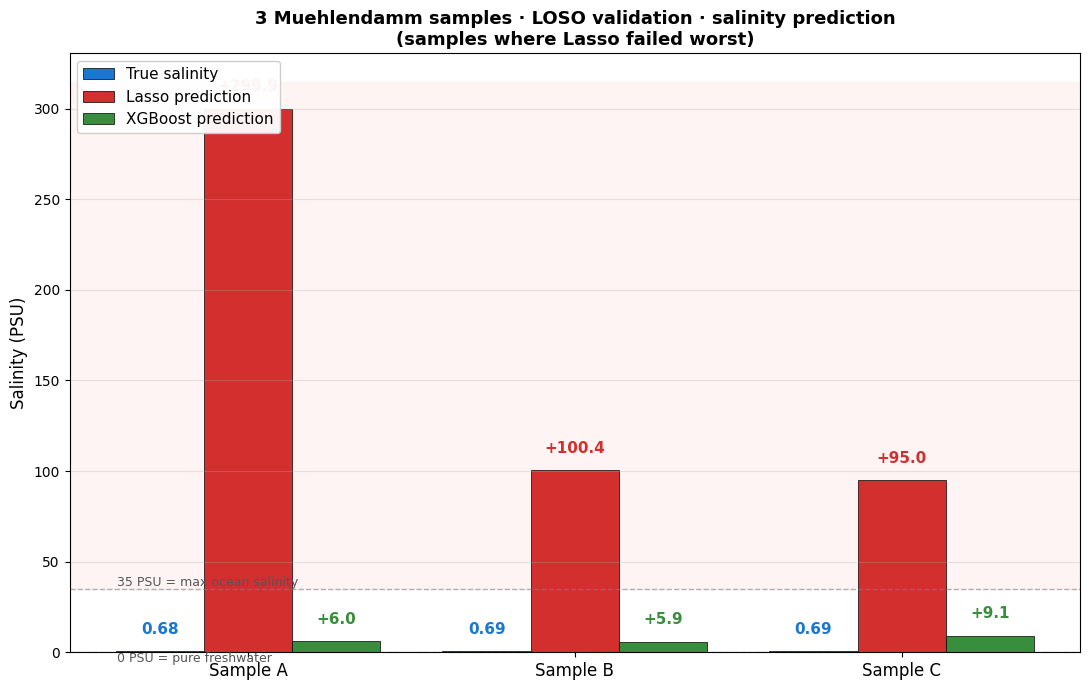


3 worst Muehlendamm samples under Lasso × LOSO × salinity:

                   True     Lasso pred   XGBoost pred
----------------------------------------------------
Sample A            0.68         +299.92           +6.03
Sample B            0.69         +100.39           +5.89
Sample C            0.69          +94.99           +9.11


In [21]:

import matplotlib.pyplot as plt
import numpy as np

# Pick the run where Lasso failed worst: LOSO × salinity
lasso_loso = all_predictions[('leave_one_site_out', 'Lasso')]
xgb_loso   = all_predictions[('leave_one_site_out', 'XGBoost')]

# Get Muehlendamm samples (preserving order)
md_l = lasso_loso[lasso_loso['site'] == 'Muehlendamm'].reset_index(drop=True)
md_x = xgb_loso[xgb_loso['site']   == 'Muehlendamm'].reset_index(drop=True)
assert (md_l['y_true'].values == md_x['y_true'].values).all()

# 3 samples with worst Lasso prediction error
md_l['abs_err'] = (md_l['y_pred'] - md_l['y_true']).abs()
idx = md_l['abs_err'].nlargest(3).index
s_lasso = md_l.loc[idx].reset_index(drop=True)
s_xgb   = md_x.loc[idx].reset_index(drop=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(3)
w = 0.27

b1 = ax.bar(x - w, s_lasso['y_true'],  w, label='True salinity',       color='#1976D2', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,     s_lasso['y_pred'],  w, label='Lasso prediction',    color='#D32F2F', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + w, s_xgb['y_pred'],    w, label='XGBoost prediction',  color='#388E3C', edgecolor='black', linewidth=0.5)

# Annotate each bar with its value
for bars, vals, color in [(b1, s_lasso['y_true'], '#1976D2'),
                          (b2, s_lasso['y_pred'], '#D32F2F'),
                          (b3, s_xgb['y_pred'],   '#388E3C')]:
    for bar, v in zip(bars, vals):
        h = bar.get_height()
        offset = 8 if h >= 0 else -8
        va = 'bottom' if h >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                f"{v:+.1f}" if abs(v) > 1 else f"{v:.2f}",
                ha='center', va=va, fontsize=11, fontweight='bold', color=color)

# Physical reality lines
ax.axhline(0,  color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(35, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.text(-0.4, 35, '35 PSU = max ocean salinity', fontsize=9, color='#555', va='bottom')
ax.text(-0.4, 0,  '0 PSU = pure freshwater',     fontsize=9, color='#555', va='top')

# Shade physically impossible zones
y_min, y_max = ax.get_ylim()
if y_min < 0:
    ax.axhspan(y_min, 0,  color='#FFE5E5', alpha=0.4, zorder=0)
if y_max > 35:
    ax.axhspan(35, y_max, color='#FFE5E5', alpha=0.4, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(['Sample A', 'Sample B', 'Sample C'], fontsize=12)
ax.set_ylabel('Salinity (PSU)', fontsize=12)
ax.set_title('3 Muehlendamm samples · LOSO validation · salinity prediction\n'
             '(samples where Lasso failed worst)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/three_samples_salinity.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print the table too
print("\n3 worst Muehlendamm samples under Lasso × LOSO × salinity:\n")
print(f"{'':12} {'True':>10} {'Lasso pred':>14} {'XGBoost pred':>14}")
print("-" * 52)
for i in range(3):
    print(f"Sample {chr(65+i):<5}  "
          f"{s_lasso['y_true'].iloc[i]:>10.2f}  "
          f"{s_lasso['y_pred'].iloc[i]:>+14.2f}  "
          f"{s_xgb['y_pred'].iloc[i]:>+14.2f}")

Total negative predictions: 247

              strategy   model                    site    y_true      y_pred
          random_kfold   Lasso             Muehlendamm  0.838213   -0.671331
          random_kfold   Lasso             Muehlendamm  0.574800   -3.651990
          random_kfold   Lasso             Muehlendamm  0.619773   -2.925295
          random_kfold   Lasso             Muehlendamm  0.100000   -1.668458
          random_kfold   Lasso             Muehlendamm  0.100000   -0.645735
          random_kfold   Lasso             Muehlendamm  0.604000   -5.068217
          random_kfold   Lasso             Muehlendamm  0.571000   -7.436817
          random_kfold   Lasso      Stadthafen Rostock  1.098000   -0.800996
          random_kfold   Lasso             Muehlendamm  0.710000   -1.067233
          random_kfold   Lasso             Muehlendamm  0.567000  -11.647601
          random_kfold   Lasso             Muehlendamm  0.100000   -3.772245
          random_kfold   Lasso             

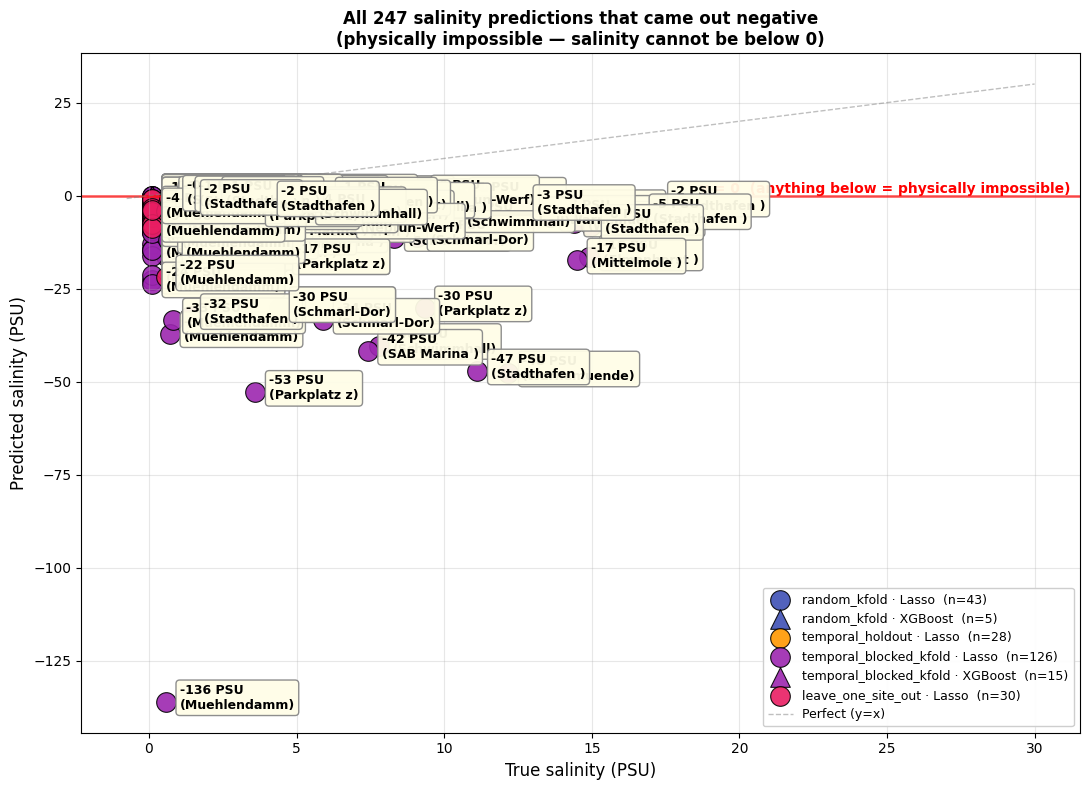

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# جمع‌آوری همه‌ی پیش‌بینی‌های منفی از ۸ ترکیب
records = []
for (strategy, model), df in all_predictions.items():
    neg = df[df['y_pred'] < 0].copy()
    if len(neg):
        neg['strategy'] = strategy
        neg['model']    = model
        records.append(neg)

neg_df = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
print(f"Total negative predictions: {len(neg_df)}\n")
print(neg_df[['strategy', 'model', 'site', 'y_true', 'y_pred']].to_string(index=False))

# --- نمودار ---
fig, ax = plt.subplots(figsize=(11, 8))

colors  = {'random_kfold': '#3F51B5',
           'temporal_holdout': '#FF9800',
           'temporal_blocked_kfold': '#9C27B0',
           'leave_one_site_out': '#E91E63'}
markers = {'Lasso': 'o', 'XGBoost': '^'}

for strategy in colors:
    for model in markers:
        sub = neg_df[(neg_df['strategy'] == strategy) & (neg_df['model'] == model)]
        if len(sub):
            ax.scatter(sub['y_true'], sub['y_pred'],
                       c=colors[strategy], marker=markers[model],
                       s=200, alpha=0.9, edgecolor='black', linewidth=0.8,
                       label=f'{strategy} · {model}  (n={len(sub)})')

# خط y=0 (مرز فیزیکی — همه‌چی پایینش غیرممکن)
ax.axhline(0, color='red', linewidth=1.8, alpha=0.7, linestyle='-')
ax.text(0.99, 0.005, ' y = 0  (anything below = physically impossible)',
        transform=ax.get_yaxis_transform(),
        fontsize=10, color='red', va='bottom', ha='right', fontweight='bold')

# خط y=x به عنوان مرجع
xl = ax.get_xlim()
ax.plot([xl[0], 30], [xl[0], 30],
        color='gray', linestyle='--', linewidth=1, alpha=0.5,
        label='Perfect (y=x)')

# عدد دقیق روی هر نقطه + اسم سایت
for _, row in neg_df.iterrows():
    site_short = row['site'][:11]
    ax.annotate(f"{row['y_pred']:+.0f} PSU\n({site_short})",
                xy=(row['y_true'], row['y_pred']),
                xytext=(10, -5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#FFFDE7', edgecolor='#888', alpha=0.95))

ax.set_xlabel('True salinity (PSU)', fontsize=12)
ax.set_ylabel('Predicted salinity (PSU)', fontsize=12)
ax.set_title(f'All {len(neg_df)} salinity predictions that came out negative\n'
             '(physically impossible — salinity cannot be below 0)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/negative_predictions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Saved: ../results/parity_lasso_vs_xgboost_v3.png


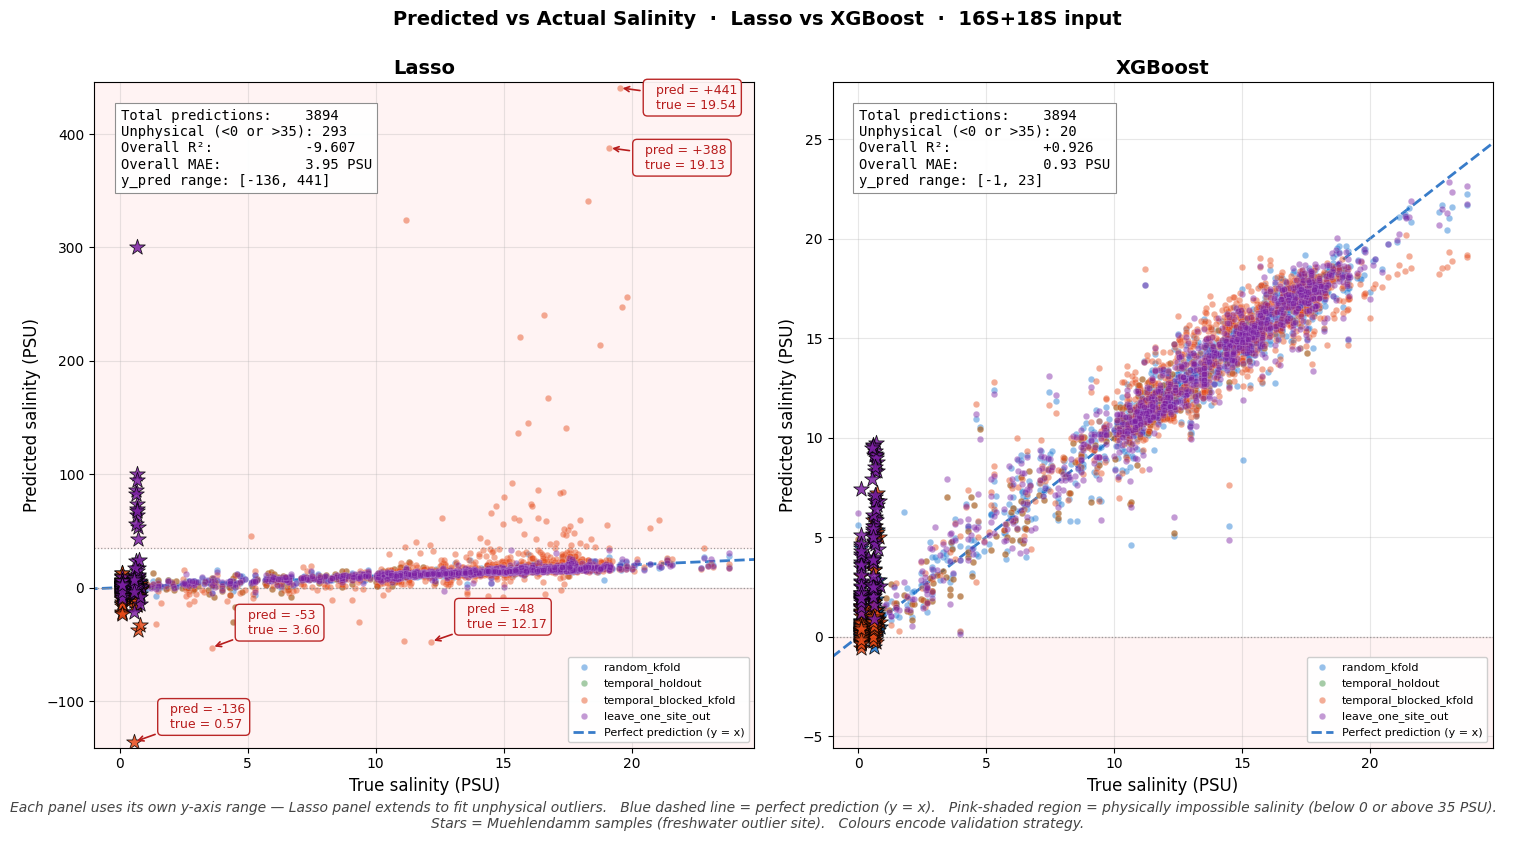


Lasso outliers (predictions outside physical range 0-35 PSU):
Total: 293 unphysical predictions out of 3894
              strategy                 site    y_true      y_pred
temporal_blocked_kfold          Muehlendamm  0.571000 -136.027142
temporal_blocked_kfold Parkplatz zur Warnow  3.600000  -52.874655
temporal_blocked_kfold   Warnemuende Strand 12.173212  -47.675046
temporal_blocked_kfold   Stadthafen Rostock 11.125000  -47.127146
temporal_blocked_kfold    SAB Marina Bramow  7.407719  -41.832183
...
              strategy                   site  y_true     y_pred
    leave_one_site_out            Muehlendamm   0.675 299.919032
temporal_blocked_kfold     Stadthafen Rostock  11.171 324.045002
temporal_blocked_kfold     Stadthafen Rostock  18.315 341.081545
temporal_blocked_kfold   Parkplatz zur Warnow  19.131 387.705709
temporal_blocked_kfold Schwimmhalle Gehlsdorf  19.542 440.679428

XGBoost outliers:
Total: 20 unphysical predictions out of 3894
              strategy               

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

# --- جمع‌آوری همه‌ی پیش‌بینی‌های salinity در یک DataFrame ---
all_rows = []
for (strategy, model), df in all_predictions.items():
    sub = df.copy()
    sub['strategy'] = strategy
    sub['model']    = model
    all_rows.append(sub)
combined = pd.concat(all_rows, ignore_index=True)

# --- تنظیمات ---
PHYS_MIN, PHYS_MAX = 0, 35   # محدوده‌ی فیزیکی شوری
strategy_colors = {
    'random_kfold':           '#1976D2',
    'temporal_holdout':       '#388E3C',
    'temporal_blocked_kfold': '#E64A19',
    'leave_one_site_out':     '#7B1FA2',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for ax, model_name in zip(axes, ['Lasso', 'XGBoost']):
    df_m = combined[combined['model'] == model_name]

    # نقاط هر strategy با رنگ متفاوت
    for strategy, color in strategy_colors.items():
        sub = df_m[df_m['strategy'] == strategy]
        is_md = sub['site'] == 'Muehlendamm'

        # نقاط معمولی — دایره
        ax.scatter(sub.loc[~is_md, 'y_true'], sub.loc[~is_md, 'y_pred'],
                   c=color, s=22, alpha=0.45, zorder=2,
                   edgecolor='white', linewidth=0.2,
                   label=f'{strategy}')
        # Muehlendamm — ستاره با حاشیه‌ی سیاه
        ax.scatter(sub.loc[is_md, 'y_true'], sub.loc[is_md, 'y_pred'],
                   c=color, marker='*', s=140, alpha=0.85, zorder=3,
                   edgecolor='black', linewidth=0.6)

    # محدوده‌ی محور — مستقل برای هر panel
    y_min = df_m['y_pred'].min() - 5
    y_max = df_m['y_pred'].max() + 5
    x_min = -1
    x_max = df_m['y_true'].max() + 1

    # سایه‌ی منطقه‌ی غیرفیزیکی
    if y_min < PHYS_MIN:
        ax.axhspan(y_min, PHYS_MIN, color='#FFE5E5', alpha=0.45, zorder=0)
    if y_max > PHYS_MAX:
        ax.axhspan(PHYS_MAX, y_max, color='#FFE5E5', alpha=0.45, zorder=0)

    # خطوط مرز فیزیکی
    ax.axhline(0,  color='#888', linewidth=0.9, linestyle=':', alpha=0.8)
    ax.axhline(35, color='#888', linewidth=0.9, linestyle=':', alpha=0.8)

    # خط y=x (پیش‌بینی کامل) — آبی نقطه‌چین، ضخیم و واضح
    lim = [min(x_min, y_min), max(x_max, y_max)]
    ax.plot(lim, lim, color='#1565C0', linestyle='--', linewidth=2,
            alpha=0.85, zorder=1, label='Perfect prediction (y = x)')

    # annotation روی outlier های منفی
    if model_name == 'Lasso':
        worst_neg = df_m[df_m['y_pred'] < 0].nsmallest(3, 'y_pred')
        for _, row in worst_neg.iterrows():
            ax.annotate(f"  pred = {row['y_pred']:+.0f}\n  true = {row['y_true']:.2f}",
                        xy=(row['y_true'], row['y_pred']),
                        xytext=(20, 10), textcoords='offset points',
                        fontsize=9, color='#B71C1C',
                        bbox=dict(boxstyle='round,pad=0.35',
                                  facecolor='#FFF5F5', edgecolor='#B71C1C',
                                  alpha=0.95, linewidth=1),
                        arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

        # annotation روی outlier های خیلی بزرگ مثبت
        worst_pos = df_m[df_m['y_pred'] > 50].nlargest(2, 'y_pred')
        for _, row in worst_pos.iterrows():
            ax.annotate(f"  pred = {row['y_pred']:+.0f}\n  true = {row['y_true']:.2f}",
                        xy=(row['y_true'], row['y_pred']),
                        xytext=(20, -15), textcoords='offset points',
                        fontsize=9, color='#B71C1C',
                        bbox=dict(boxstyle='round,pad=0.35',
                                  facecolor='#FFF5F5', edgecolor='#B71C1C',
                                  alpha=0.95, linewidth=1),
                        arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

    # box آماری
    n_total = len(df_m)
    n_unphys = ((df_m['y_pred'] < PHYS_MIN) | (df_m['y_pred'] > PHYS_MAX)).sum()
    r2_overall  = r2_score(df_m['y_true'], df_m['y_pred'])
    mae_overall = mean_absolute_error(df_m['y_true'], df_m['y_pred'])

    info_lines = [
        f"Total predictions:    {n_total}",
        f"Unphysical (<0 or >35): {n_unphys}",
        f"Overall R²:           {r2_overall:+.3f}",
        f"Overall MAE:          {mae_overall:.2f} PSU",
        f"y_pred range: [{df_m['y_pred'].min():.0f}, {df_m['y_pred'].max():.0f}]",
    ]
    info_text = "\n".join(info_lines)
    ax.text(0.04, 0.96, info_text,
            transform=ax.transAxes,
            verticalalignment='top', fontsize=10, family='monospace',
            bbox=dict(facecolor='white', alpha=0.95,
                      edgecolor='#888', linewidth=0.8))

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('True salinity (PSU)', fontsize=12)
    ax.set_ylabel('Predicted salinity (PSU)', fontsize=12)
    ax.set_title(model_name, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8, framealpha=0.95)

fig.suptitle('Predicted vs Actual Salinity  ·  Lasso vs XGBoost  ·  16S+18S input',
             fontsize=14, fontweight='bold', y=1.00)

# Caption پایین شکل
caption = ('Each panel uses its own y-axis range — Lasso panel extends to fit unphysical outliers.   '
           'Blue dashed line = perfect prediction (y = x).   '
           'Pink-shaded region = physically impossible salinity (below 0 or above 35 PSU).   '
           'Stars = Muehlendamm samples (freshwater outlier site).   '
           'Colours encode validation strategy.')
fig.text(0.5, -0.02, caption, ha='center', fontsize=10,
         style='italic', color='#444', wrap=True)

plt.tight_layout()
out_path = Path("../results/parity_lasso_vs_xgboost_v3.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out_path}")
plt.show()

# --- خلاصه‌ی متنی outlier ها ---
print("\n" + "=" * 70)
print("Lasso outliers (predictions outside physical range 0-35 PSU):")
print("=" * 70)
lasso_outliers = combined[(combined['model'] == 'Lasso') &
                          ((combined['y_pred'] < 0) | (combined['y_pred'] > 35))]
print(f"Total: {len(lasso_outliers)} unphysical predictions out of {(combined['model']=='Lasso').sum()}")
print(lasso_outliers[['strategy', 'site', 'y_true', 'y_pred']]
      .sort_values('y_pred').head(5).to_string(index=False))
print("...")
print(lasso_outliers[['strategy', 'site', 'y_true', 'y_pred']]
      .sort_values('y_pred').tail(5).to_string(index=False))

print("\nXGBoost outliers:")
xgb_outliers = combined[(combined['model'] == 'XGBoost') &
                        ((combined['y_pred'] < 0) | (combined['y_pred'] > 35))]
print(f"Total: {len(xgb_outliers)} unphysical predictions out of {(combined['model']=='XGBoost').sum()}")
if len(xgb_outliers):
    print(xgb_outliers[['strategy', 'site', 'y_true', 'y_pred']].to_string(index=False))